# Libraries

In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('../src') 

from utils.constants import PROJECT_CRS
from tables_setup import *
from utils.paths import *
from utils.data_processing import *
from utils.sedona_config import get_spark

import string
import time
import logging
import pandas as pd
import geopandas as gpd
import pydeck as pdk
from sedona.maps.SedonaKepler import SedonaKepler
from sedona.maps.SedonaPyDeck import SedonaPyDeck
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
sedona = get_spark()
tables = load_tables(sedona)

25/08/07 12:02:19 WARN Utils: Your hostname, kinabalu resolves to a loopback address: 127.0.1.1; using 128.232.93.1 instead (on interface eno12399np0)
25/08/07 12:02:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
https://artifacts.unidata.ucar.edu/repository/unidata-all added as a remote repository with the name: repo-1
Ivy Default Cache set to: /home/acz25/.ivy2/cache
The jars for the packages stored in: /home/acz25/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
net.postgis#postgis-jdbc added as a dependency
net.postgis#postgis-geometry added as a dependency
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-232827b0-f2d1-4e6b-a7ff-2d07bd1d0cff;1.0
	confs: [default]


:: loading settings :: url = jar:file:/maps-priv/maps/acz25/miniconda3/envs/3-30-300-env/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.0 in user-list
	found org.apache.sedona#sedona-common;1.7.0 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in user-list
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-annotations;1.1 in central
	found org.codehaus.mojo#animal-sniffer-annotations;1.14 in central
	found com.uber#h3;4.1.1 in central
	found net.sf.geographiclib#GeographicLib-Java;1.52 in central
	found com.github.ben-manes.caffeine#caffeine;2.9.2 in central
	found org.checkerframework#checker-qual;3.10.0 in central
	found com.google.e

In [3]:
output_areas_boundaries_gdf = tables['output_areas_boundaries_gdf'] 
os_tile_boundaries_gdf = tables['os_tile_boundaries_gdf'] 
output_areas_os_tile_overlay_df = tables['output_areas_os_tile_overlay_df']
output_areas_buildings_overlay_sdf = tables['output_areas_buildings_overlay_sdf']
vom_raster_paths_df = tables['vom_raster_paths_df'] 
tree_vector_paths_df = tables['tree_vector_paths_df']
road_nodes_gdf = tables['road_nodes_gdf'] 
road_edges_gdf = tables['road_edges_gdf']
green_space_site_gdf = tables['green_space_site_gdf']
green_space_access_gdf = tables['green_space_access_gdf']
buildings_sdf = tables['buildings_sdf']

In [4]:
output_areas_boundaries_sdf = sedona.createDataFrame(output_areas_boundaries_gdf)
output_areas_boundaries_sdf.createOrReplaceTempView('boundaries')
buildings_sdf.createOrReplaceTempView("buildings")
output_areas_buildings_overlay_sdf.createOrReplaceTempView('output_areas_buildings_overlay')
public_park_site_gdf = green_space_site_gdf.copy()[green_space_site_gdf['function'] == 'Public Park Or Garden'].reset_index(drop=True)
public_park_site_sdf = sedona.createDataFrame(public_park_site_gdf)
public_park_site_sdf.createOrReplaceTempView('public_park_sites')
public_park_access_gdf = green_space_access_gdf.copy()[green_space_access_gdf['ref_to_greenspace_site'].isin(public_park_site_gdf.id)].reset_index(drop=True)
public_park_access_sdf = sedona.createDataFrame(public_park_access_gdf)
public_park_access_sdf.createOrReplaceTempView('public_park_accesses')
imd_lsoa_gdf = tables['imd_lsoa_gdf']
imd_lsoa_sdf = sedona.createDataFrame(imd_lsoa_gdf)
imd_lsoa_sdf.createOrReplaceTempView('imd')

In [5]:
trees_geoparquet_dir = T3_30_300_DIR / "VOM_Trees_unique"
trees_sdf = sedona.read.format("geopackage").option("tableName", "trees").load(str(trees_geoparquet_dir))
trees_sdf.createOrReplaceTempView('trees')

In [9]:
geo_level = 'LAD22CD'
geo_code = 'E07000008'  # Cambridge: E07000008

In [108]:
t3_300_sdf = sedona.read.format("parquet").load(str(database_dir / 't3_300.parquet'))
t3_300_sdf.createOrReplaceTempView('t3_300')
t3_300_sdf.printSchema()

root
 |-- verisk_premise_id: long (nullable = true)
 |-- closest_park_access_id: string (nullable = true)
 |-- distance_manhattan: double (nullable = true)
 |-- closest_park_site_id: string (nullable = true)
 |-- distance_euclidean: double (nullable = true)
 |-- tree_count_10m: double (nullable = true)
 |-- tree_count_25m: double (nullable = true)
 |-- tree_count_50m: double (nullable = true)
 |-- tree_count_75m: double (nullable = true)
 |-- tree_count_100m: double (nullable = true)
 |-- tree_count_slope: double (nullable = true)
 |-- park_distance_ratio: double (nullable = true)
 |-- park_distance_diff: double (nullable = true)



In [6]:
geo_boundaries_imd_sdf = sedona.sql(f"""
SELECT i.*, b.geometry FROM imd i
FULL JOIN boundaries b ON i.LSOA21CD = b.LSOA21CD
WHERE b.{geo_level} = '{geo_code}'""")
geo_boundaries_imd_sdf.printSchema()

root
 |-- LSOA11CD: string (nullable = true)
 |-- LSOA21CD: string (nullable = true)
 |-- IMD_Rank: long (nullable = true)
 |-- IMD_Decile: long (nullable = true)
 |-- IMDScore: double (nullable = true)
 |-- IncScore: double (nullable = true)
 |-- IncRank: long (nullable = true)
 |-- IncDec: long (nullable = true)
 |-- EmpScore: double (nullable = true)
 |-- EmpRank: long (nullable = true)
 |-- EmpDec: long (nullable = true)
 |-- EduScore: double (nullable = true)
 |-- EduRank: long (nullable = true)
 |-- EduDec: long (nullable = true)
 |-- HDDScore: double (nullable = true)
 |-- HDDRank: long (nullable = true)
 |-- HDDDec: long (nullable = true)
 |-- CriScore: double (nullable = true)
 |-- CriRank: long (nullable = true)
 |-- CriDec: long (nullable = true)
 |-- BHSScore: double (nullable = true)
 |-- BHSRank: long (nullable = true)
 |-- BHSDec: long (nullable = true)
 |-- EnvScore: double (nullable = true)
 |-- EnvRank: long (nullable = true)
 |-- EnvDec: long (nullable = true)
 |-- g

In [7]:
geo_buildings_sdf = sedona.sql(f"""
SELECT b.verisk_premise_id, b.map_use, b.height, b.distance_water, t3.tree_count_10m, t3.tree_count_25m, t3.tree_count_slope,
t3.tree_count_50m, t3.tree_count_75m, t3.tree_count_100m, t3.distance_manhattan, t3.distance_euclidean, 
t3.park_distance_ratio, t3.park_distance_diff, oab.LSOA21CD,
b.geometry FROM buildings b
JOIN output_areas_buildings_overlay oab ON b.verisk_premise_id = oab.verisk_premise_id
LEFT JOIN t3_300 t3 ON b.verisk_premise_id = t3.verisk_premise_id
WHERE oab.{geo_level} = '{geo_code}' AND b.map_use = 'Residential'
AND t3.distance_manhattan IS NOT NULL
""")
geo_buildings_sdf.printSchema()

AnalysisException: [TABLE_OR_VIEW_NOT_FOUND] The table or view `t3_300` cannot be found. Verify the spelling and correctness of the schema and catalog.
If you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.
To tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS.; line 7 pos 10;
'Project ['b.verisk_premise_id, 'b.map_use, 'b.height, 'b.distance_water, 't3.tree_count_10m, 't3.tree_count_25m, 't3.tree_count_slope, 't3.tree_count_50m, 't3.tree_count_75m, 't3.tree_count_100m, 't3.distance_manhattan, 't3.distance_euclidean, 't3.park_distance_ratio, 't3.park_distance_diff, 'oab.LSOA21CD, 'b.geometry]
+- 'Filter ((('oab.LAD22CD = E07000008) AND ('b.map_use = Residential)) AND isnotnull('t3.distance_manhattan))
   +- 'Join LeftOuter, ('b.verisk_premise_id = 't3.verisk_premise_id)
      :- Join Inner, (verisk_premise_id#42L = verisk_premise_id#19L)
      :  :- SubqueryAlias b
      :  :  +

In [114]:
geo_trees_sdf = sedona.sql(f"""SELECT t.* FROM trees t
                               LEFT JOIN boundaries b
                               ON ST_INTERSECTS(t.geometry, b.geometry)
                               WHERE b.{geo_level} = '{geo_code}'""")
geo_trees_sdf.printSchema()

root
 |-- treeID: long (nullable = true)
 |-- height: double (nullable = true)
 |-- area: double (nullable = true)
 |-- geometry: geometry (nullable = true)



In [115]:
geo_boundaries_imd_gdf = gpd.GeoDataFrame(geo_boundaries_imd_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)
geo_buildings_gdf = gpd.GeoDataFrame(geo_buildings_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)
geo_trees_gdf = gpd.GeoDataFrame(geo_trees_sdf.toPandas(), geometry='geometry', crs=PROJECT_CRS)

25/07/22 19:03:09 WARN JoinQuery: UseIndex is true, but no index exists. Will build index on the fly.
25/07/22 19:03:09 WARN TaskSetManager: Stage 701 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.


In [116]:
geo_boundaries_imd_gdf.to_crs('EPSG:4326').to_parquet("geo_boundaries_imd.parquet", index=False)
geo_buildings_gdf.to_crs('EPSG:4326').to_parquet("geo_buildings.parquet", index=False)
geo_trees_gdf.to_crs('EPSG:4326').to_parquet("geo_trees.parquet", index=False)

In [118]:
geo_buildings_filt_gdf = geo_buildings_gdf.copy()[((geo_buildings_gdf['tree_count_slope'] > 0) & (geo_buildings_gdf['map_use'] == 'Residential')) & (geo_buildings_gdf['tree_count_25m'] > 1)]
max_id = geo_buildings_filt_gdf.loc[geo_buildings_filt_gdf['tree_count_slope'].idxmax(), 'verisk_premise_id']
min_id = geo_buildings_filt_gdf.loc[geo_buildings_filt_gdf['tree_count_slope'].idxmin(), 'verisk_premise_id']
my_id = 10605295
print("Highest tree_count_slope verisk_premise_id:", max_id)
print("Lowest tree_count_slope verisk_premise_id:", min_id)

Highest tree_count_slope verisk_premise_id: 22405698
Lowest tree_count_slope verisk_premise_id: 1516976


/tmp/ipykernel_2278001/2460996133.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  trees_in_buffer.plot(ax=ax, color='darkgreen', markersize=5, label='Trees')
/tmp/ipykernel_2278001/2460996133.py:36: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  trees_in_buffer.plot(ax=ax, color='darkgreen', markersize=5, label='Trees')


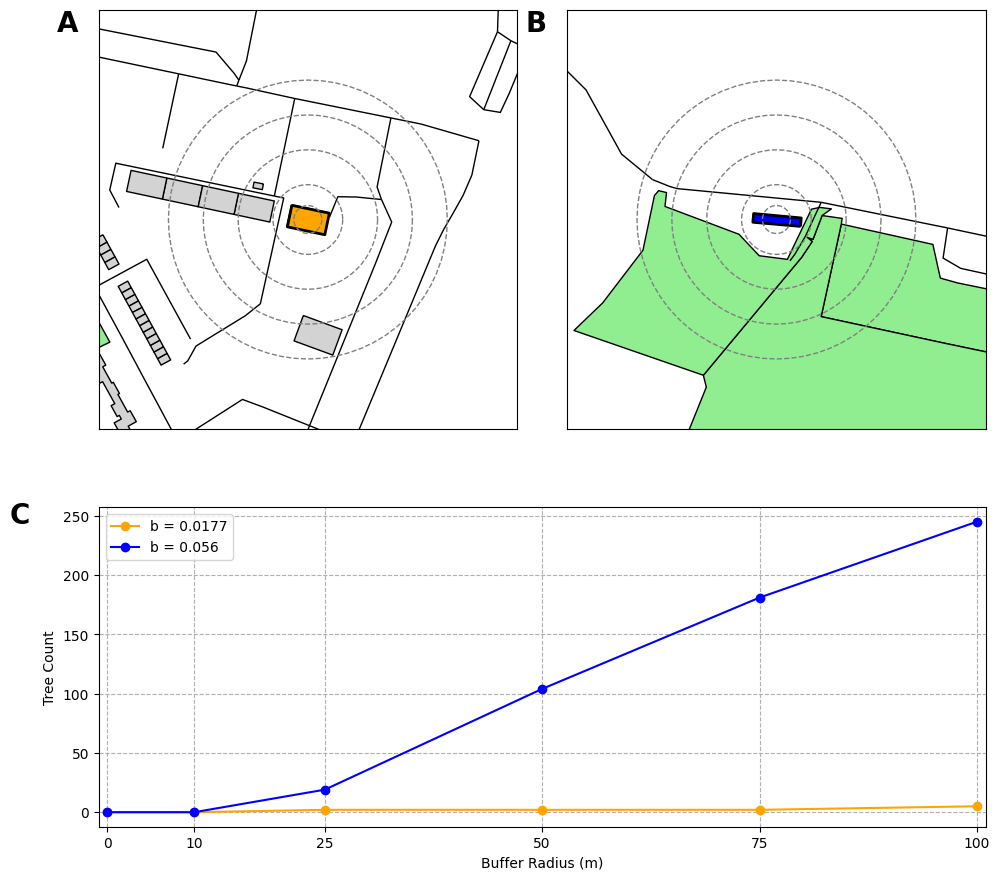

In [119]:
# Create figure with 2 rows - maps on top, line plot on bottom
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Plot maps in top row
for i, (ax, building_id, title, color) in enumerate([(ax1, min_id, 'Minimum Tree Count', 'orange'), (ax2, max_id, 'Maximum Tree Count', 'blue')]):
    selected_building = geo_buildings_gdf[geo_buildings_gdf['verisk_premise_id'] == building_id]
    center_point = selected_building.geometry.iloc[0].centroid
    
    # Create square buffer
    buffer_size = 150
    minx, miny = center_point.x - buffer_size, center_point.y - buffer_size
    maxx, maxy = center_point.x + buffer_size, center_point.y + buffer_size
    square_buffer_geom = box(minx, miny, maxx, maxy)

    # Get features within buffer
    roads_in_buffer = road_edges_gdf[road_edges_gdf.geometry.intersects(square_buffer_geom)]
    green_space_in_buffer = green_space_site_gdf[green_space_site_gdf.geometry.intersects(square_buffer_geom)]
    buildings_in_buffer = geo_buildings_gdf[geo_buildings_gdf.geometry.centroid.within(square_buffer_geom)]
    trees_in_buffer = geo_trees_gdf[geo_trees_gdf.geometry.within(square_buffer_geom)]

    # Plot features
    roads_in_buffer.plot(ax=ax, color='black', linewidth=1, label='Roads')
    buildings_in_buffer.plot(ax=ax, facecolor='lightgrey', edgecolor='k', label='Buildings')
    green_space_in_buffer.plot(ax=ax, facecolor='lightgreen', edgecolor='k', label='Green Spaces')

    # Plot tree buffers
    for r in [10, 25, 50, 75, 100]:
        tree_buffer_gsf = gpd.GeoSeries([center_point.buffer(r)], crs=PROJECT_CRS)
        tree_buffer_gsf.boundary.plot(ax=ax, color='grey', linestyle='--', linewidth=1)

    trees_in_buffer.plot(ax=ax, color='darkgreen', markersize=5, label='Trees')
    selected_building.plot(ax=ax, facecolor=color, edgecolor='k', linewidth=2, label='Selected Building')

    ax.set_xlim([square_buffer_geom.bounds[0], square_buffer_geom.bounds[2]])
    ax.set_ylim([square_buffer_geom.bounds[1], square_buffer_geom.bounds[3]])
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')
    # ax.set_title(title)
    ax.text(-0.1, 0.95, string.ascii_uppercase[i], transform=ax.transAxes, 
    size=20, weight='bold')
# Plot line graph in bottom row
radii = [0, 10, 25, 50, 75, 100]
for building_id, label, color in [(min_id, 'Minimum Tree Count Building', 'orange'), (max_id, 'Maximum Tree Count Building', 'blue')]:
    selected_building = geo_buildings_gdf[geo_buildings_gdf['verisk_premise_id'] == building_id]
    tree_counts = [0] + [selected_building[f'tree_count_{r}m'].iloc[0] for r in radii[1:]]
    ax3.plot(radii, tree_counts, marker='o', label="b = " + str(selected_building['tree_count_slope'].values[0]), color=color)

ax3.set_xlabel('Buffer Radius (m)')
ax3.set_ylabel('Tree Count')
ax3.legend()
ax3.grid(True, linestyle='--')
ax3.set_xlim([-1, 101])
ax3.set_xticks([0, 10, 25, 50, 75, 100])
ax3.text(-0.1, 0.95, string.ascii_uppercase[2], transform=ax3.transAxes, 
            size=20, weight='bold')
plt.tight_layout()
# plt.savefig("../images/tree_count_slope_plots.png", transparent=True)
plt.show()


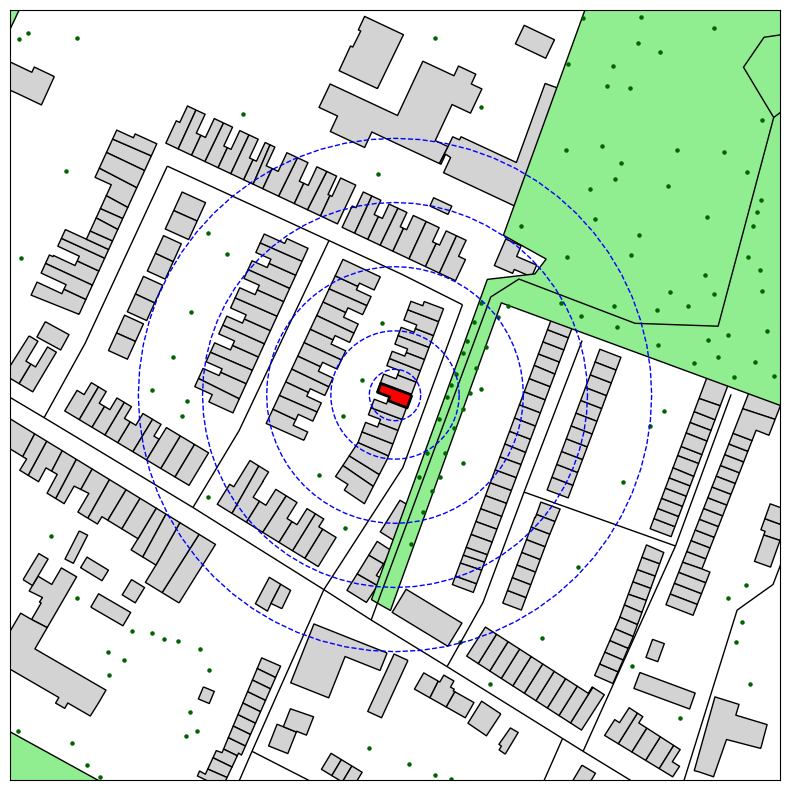

In [38]:
import matplotlib.pyplot as plt


# Get the building geometry for the selected verisk_id
selected_building = geo_buildings_gdf[geo_buildings_gdf['verisk_premise_id'] == my_id]

center_geom = selected_building.geometry.iloc[0]
center_point = center_geom.centroid

# Buffer of x meters around the selected building
buffer_size = 150
buffer_geom = center_point.buffer(buffer_size)
# Create a square buffer (bounding box) around the centroid
minx, miny = center_point.x - buffer_size, center_point.y - buffer_size
maxx, maxy = center_point.x + buffer_size, center_point.y + buffer_size
square_buffer_geom = box(minx, miny, maxx, maxy)

roads_in_buffer = road_edges_gdf[road_edges_gdf.geometry.intersects(square_buffer_geom)]
green_space_in_buffer = green_space_site_gdf[green_space_site_gdf.geometry.intersects(square_buffer_geom)]
buildings_in_buffer = geo_buildings_gdf[geo_buildings_gdf.geometry.centroid.within(square_buffer_geom)]
trees_in_buffer = geo_trees_gdf[geo_trees_gdf.geometry.within(square_buffer_geom)]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
# Draw buffer circle
# buffer_gsf = gpd.GeoSeries([buffer_geom], crs=PROJECT_CRS)
# buffer_gsf.boundary.plot(ax=ax, color='lightgray', linewidth=1)
roads_in_buffer.plot(ax=ax, color='black', linewidth=1, label='Roads')
buildings_in_buffer.plot(ax=ax, facecolor='lightgrey', edgecolor='k', label='Buildings')
green_space_in_buffer.plot(ax=ax, facecolor='lightgreen', edgecolor='k', label='Green Spaces')

for r in [10, 25, 50, 75, 100]:
    tree_buffer_gsf = gpd.GeoSeries([center_point.buffer(r)], crs=PROJECT_CRS)
    tree_buffer_gsf.boundary.plot(ax=ax, color='blue', linestyle='--', linewidth=1)

trees_in_buffer.plot(ax=ax, color='darkgreen', markersize=5, label='Trees')
selected_building.plot(ax=ax, facecolor='red', edgecolor='k', linewidth=2, label='Selected Building')

plt.xlim([square_buffer_geom.bounds[0], square_buffer_geom.bounds[2]])
plt.ylim([square_buffer_geom.bounds[1], square_buffer_geom.bounds[3]])
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')
fig.savefig("../images/my_house_trees.png", transparent=True)
plt.show()

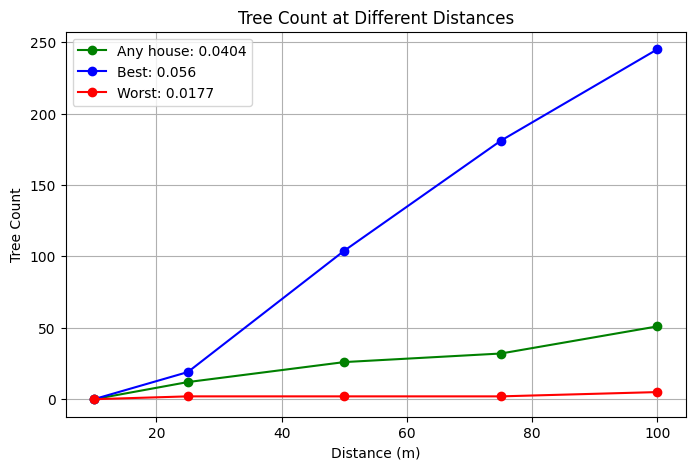

In [54]:
# List of IDs to plot
ids = [my_id, int(max_id), int(min_id)]
max_id_slope = geo_buildings_filt_gdf.loc[geo_buildings_filt_gdf['tree_count_slope'].idxmax(), 'tree_count_slope']
min_id_slope = geo_buildings_filt_gdf.loc[geo_buildings_filt_gdf['tree_count_slope'].idxmin(), 'tree_count_slope']
my_id_slope = geo_buildings_filt_gdf.loc[geo_buildings_filt_gdf['verisk_premise_id'] == my_id, 'tree_count_slope'].values[0]
labels = [f"Any house: {my_id_slope}",
          f"Best: {max_id_slope}", 
          f"Worst: {min_id_slope}"]
colors = ['green', 'blue', 'red']

# Columns to plot
tree_count_cols = ['tree_count_10m', 'tree_count_25m', 'tree_count_50m', 'tree_count_75m', 'tree_count_100m']
distances = [10, 25, 50, 75, 100]

plt.figure(figsize=(8, 5))

for id_val, label, color in zip(ids, labels, colors):
    row = geo_buildings_gdf[geo_buildings_gdf['verisk_premise_id'] == id_val]
    if not row.empty:
        values = [row[col].values[0] for col in tree_count_cols]
        plt.plot(distances, values, marker='o', label=label, color=color)

plt.xlabel('Distance (m)')
plt.ylabel('Tree Count')
plt.title('Tree Count at Different Distances')
plt.legend()
plt.grid(True)
plt.savefig("../images/tree_slope.png", transparent=True)
plt.show()

<Figure size 2000x1000 with 0 Axes>

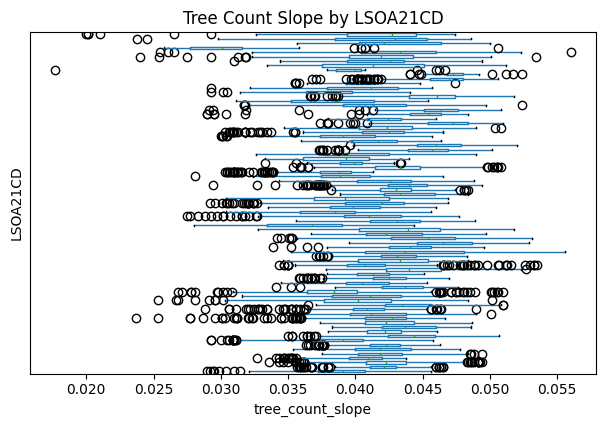

In [69]:
plt.figure(figsize=(20, 10))
geo_buildings_filt_gdf.boxplot(column='tree_count_slope', by='LSOA21CD', grid=False, rot=90, vert=False)
plt.title('Tree Count Slope by LSOA21CD')
plt.suptitle('')
plt.xlabel('tree_count_slope')
plt.tight_layout()
plt.yticks([])
plt.show()

## PyDeck

In [ ]:
SedonaPyDeck.create_choropleth_map(geo_buildings_sdf, plot_col='park_distance_ratio')

In [15]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType
from matplotlib import cm
from matplotlib.colors import Normalize
# Initialize the colormap and normalization
cmap = cm.get_cmap('PiYG_r')
norm = Normalize(vmin=geo_buildings_sdf.select("log_distance_manhattan").rdd.flatMap(lambda x: x).min(),
                 vmax=geo_buildings_sdf.select("log_distance_manhattan").rdd.flatMap(lambda x: x).max())

# Define a UDF to calculate the color
def calculate_color(value):
    normalized_value = norm(value)
    rgba_color = cmap(normalized_value)
    return f"[{int(rgba_color[0] * 255)}, {int(rgba_color[1] * 255)}, {int(rgba_color[2] * 255)}]"

color_udf = udf(calculate_color, StringType())

# Add the color column to the DataFrame
geo_buildings_sdf = geo_buildings_sdf.withColumn(
    "color", color_udf(geo_buildings_sdf["log_distance_manhattan"])
)

/tmp/ipykernel_1513422/1418024526.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PiYG_r')


AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column or function parameter with name `log_distance_manhattan` cannot be resolved. Did you mean one of the following? [`t3`.`distance_manhattan`, `b`.`distance_water`, `t3`.`distance_euclidean`, `t3`.`park_distance_ratio`, `geometry`].;
'Project ['log_distance_manhattan]
+- Project [map_use#36, height#34, distance_water#33, tree_count_10m#142, tree_count_25m#143, tree_count_slope#147, tree_count_50m#144, tree_count_75m#145, tree_count_100m#146, distance_manhattan#139, distance_euclidean#141, park_distance_ratio#148, park_distance_diff#149,  **org.apache.spark.sql.sedona_sql.expressions.ST_Transform**   AS geometry#1178]
   +- Filter (((LAD22CD#23 = E07000008) AND (map_use#36 = Residential)) AND isnotnull(distance_manhattan#139))
      +- Join LeftOuter, (verisk_premise_id#42L = verisk_premise_id#137L)
         :- Join Inner, (verisk_premise_id#42L = verisk_premise_id#19L)
         :  :- SubqueryAlias b
         :  :  +- Subquery

/tmp/ipykernel_126701/2996153227.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('PiYG_r')


<Figure size 2000x2000 with 0 Axes>

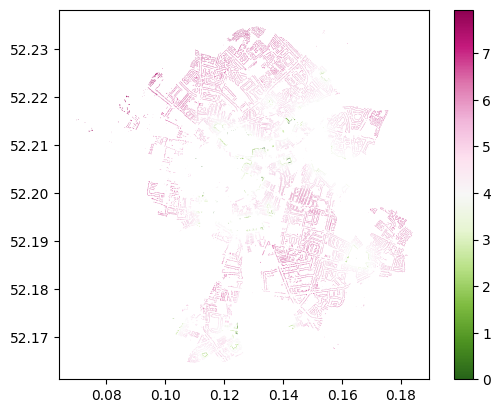

In [14]:
from matplotlib import cm
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt


plt.figure(figsize=(20, 20))
geo_buildings_gdf.plot(column='log_distance_euclidean', legend=True, cmap='PiYG_r')

# Normalize the data to the range of the colormap
norm = Normalize(vmin=geo_buildings_gdf['log_distance_euclidean'].min(), vmax=geo_buildings_gdf['log_distance_euclidean'].max())
cmap = cm.get_cmap('PiYG_r')

# Map the normalized values to colors
# geo_buildings_gdf['color'] = geo_buildings_gdf['log_distance_euclidean'].apply(lambda x: cmap(norm(x)))

In [16]:
# Load a map with data and config and height
from keplergl import KeplerGl
map_2 = KeplerGl(height=400, data={"data_1": geo_buildings_gdf[['geometry']]})
map_2

NameError: name 'geo_buildings_gdf' is not defined

In [ ]:
INITIAL_VIEW_STATE = pdk.ViewState(latitude=52.20451158061835, longitude=0.12823234624236227, zoom=11, max_zoom=17, pitch=45, bearing=0)
SedonaPyDeck.create_choropleth_map(geo_buildings_sdf, plot_col='distance_euclidean', elevation_col='height',
                                   map_style=pdk.map_styles.LIGHT, initial_view_state=INITIAL_VIEW_STATE)

In [106]:
from t3 import *

In [108]:
buffer = 100
tile_level = 'TILE_NAME_50KM'

In [110]:
geo_tree_count_df

DataFrame[verisk_premise_id: string, tree_count: bigint]

In [109]:
geo_tree_count_path = T3_dir / f"T3_{geo_code}_{buffer}m.csv"
    
get_geometries(sedona, geo_level, geo_code, True)
geo_buildings_buffer_sdf = filter_buffer_geometries(sedona, geo_level, geo_code, 'buildings', buffer)
overlapping_tiles_lst = get_overlapping_grid_tiles(output_areas_boundaries_gdf, os_tile_boundaries_gdf, geo_level, geo_code, tile_level)

geo_trees_sdf = read_vom_trees_geoparquet(sedona, overlapping_tiles_lst)
geo_buildings_buffer_rdd, geo_trees_rdd = create_spatial_rdds(geo_buildings_buffer_sdf, geo_trees_sdf, build_on_spatial_partitioned_rdd = True)
geo_tree_count_df = count_trees_rdd(sedona, geo_buildings_buffer_rdd, geo_trees_rdd, 'verisk_premise_id', using_index = True)
geo_tree_count_df.rename(columns={'tree_count': f'tree_count_{buffer}m'}, inplace=True)

geo_tree_count_df.to_csv(geo_tree_count_path, index=False)

25/07/17 09:26:03 WARN TaskSetManager: Stage 90 contains a task of very large size (3458 KiB). The maximum recommended task size is 1000 KiB.


AttributeError: 'DataFrame' object has no attribute 'rename'

In [127]:
glob.glob(Path(temp_dir) / "part-*.csv")

TypeError: 'PosixPath' object is not subscriptable

# Sedona with Rasters

In [7]:
band = "NDVI"
raw_spectral_sdf = sedona.read.format("binaryFile").load("/maps/acz25/phd-thesis-data/output/3-30-300/Spectral_tifs/Indexes/NDVI/*.tif")
raw_spectral_sdf.show()

25/06/24 18:30:28 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1639666 ms exceeds timeout 800000 ms
25/06/24 18:30:28 WARN SparkContext: Killing executors is not supported by current scheduler.
25/06/24 18:30:28 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$

Py4JError: An error occurred while calling o229.showString

In [11]:
spectral_sdf = sedona.sql("SELECT RS_FromGeoTiff(content) AS raster FROM raw_spectral_tifs")
spectral_sdf.createOrReplaceTempView("spectral_tifs")
spectral_sdf.show()

AnalysisException: [TABLE_OR_VIEW_NOT_FOUND] The table or view `raw_spectral_tifs` cannot be found. Verify the spelling and correctness of the schema and catalog.
If you did not qualify the name with a schema, verify the current_schema() output, or qualify the name with the correct schema and catalog.
To tolerate the error on drop use DROP VIEW IF EXISTS or DROP TABLE IF EXISTS.; line 1 pos 46;
'Project ['RS_FromGeoTiff('content) AS raster#231]
+- 'UnresolvedRelation [raw_spectral_tifs], [], false


# Corrections

In [7]:
%load_ext autoreload
%autoreload 2
from t3_30_300_spectral import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
t3_buffer_lst = [10, 25, 50, 75, 100]
tree_count_columns = [f"tree_count_{buffer}m" for buffer in t3_buffer_lst]
geo_level = "LSOA21CD"
sub_geo_level = "OA21CD"
# merge_output_csv(sedona, t3_buffer_lst)
# total_result = process_data(sedona, geo_level, sub_geo_level, t3_buffer_lst)
sdf_dict = read_parquet_files(sedona, t3_buffer_lst)
t3_300_sdf = merge_t3_and_t300(sedona, t3_buffer_lst)
t3_300_sdf = t3_300_sdf.fillna({var: 0 for var in tree_count_columns})
t3_300_sdf

DataFrame[verisk_premise_id: string, closest_park_access_id: string, distance_manhattan: string, closest_park_site_id: string, distance_euclidean: string, distance_water: double, map_use: string, building_area: double, tree_count_10m: string, tree_count_25m: string, tree_count_50m: string, tree_count_75m: string, tree_count_100m: string]

In [9]:
def calculate_slope(*tree_counts, buffer_lst: list[int]=[10, 25, 50, 75, 100]):
    """
    Calculates the slope of the exponential regression using the different buffer sizes.
    Args:
        tree_counts (list): The list of tree counts.
    Returns:
        float: The slope of the exponential regression.
    """

    # Extract x values from the column names
    x_values = np.array([0] + buffer_lst)  # Corresponding to tree_count_10m, tree_count_25m, etc.
    y_values = np.array(tree_counts, dtype=np.float64) + 1
    y_values = np.insert(y_values, 0, 1)
    
    # Filter out rows with invalid or missing values
    valid_indices = ~np.isnan(y_values)
    y_values = y_values[valid_indices]
    
    if len(y_values) < 2:  # Not enough points to fit a regression
        return None
    elif y_values[-1] == 1:
        return float(0)
    
    # Perform exponential regression through the origin
    def model(x, b):
        return np.exp(b * x)

    # Fit the model
    popt, _ = curve_fit(model, x_values, y_values)

    return round(float(popt[0]), 4)  # Return the estimated slope
slope_udf = udf(calculate_slope, DoubleType())

In [ ]:
t3_300_sdf = t3_300_sdf.withColumn(
        "tree_count_slope",
        slope_udf(
            col("tree_count_10m"),
            col("tree_count_25m"),
            col("tree_count_50m"),
            col("tree_count_75m"),
            col("tree_count_100m")
        )
    )
t3_300_df = t3_300_sdf.toPandas()
t3_300_df.to_parquet(t3_300_parquet)

+-----------------+----------------------+------------------+--------------------+------------------+--------------+--------------------+-------------+--------------+--------------+--------------+--------------+---------------+----------------+
|verisk_premise_id|closest_park_access_id|distance_manhattan|closest_park_site_id|distance_euclidean|distance_water|             map_use|building_area|tree_count_10m|tree_count_25m|tree_count_50m|tree_count_75m|tree_count_100m|tree_count_slope|
+-----------------+----------------------+------------------+--------------------+------------------+--------------+--------------------+-------------+--------------+--------------+--------------+--------------+---------------+----------------+
|         10000472|  A4D6E073-43DC-493...|             523.2|1E27513B-3B05-355...|             215.7|         381.8|         Residential|        177.0|             0|             0|             8|            21|             31|          0.0354|
|         10000591| 